# Exploration of the phase diagram of the Polymer dynamics model

In [2]:
import os
if 'LD_LIBRARY_PATH' in os.environ:
    del os.environ['LD_LIBRARY_PATH']

os.environ['JAX_PLATFORMS'] = ''

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()
import numpy as np
from tqdm.notebook import tqdm

## Load model

In [15]:
from omegaconf import OmegaConf
from polymer_dynamics_wi import build_model


path = "outputs/2025_08_29-20_42_53"  # new Wi data (no transform to Wi, run 1)
# path = "outputs/2025_08_29-20_43_24"  # new Wi data (no transform to Wi, run 2)
# path = "outputs/2025_08_29-20_44_56"  # new Wi data (no transform to Wi, run 3)

config = OmegaConf.load(os.path.join(path, ".hydra/config.yaml"))
model_template = build_model(config)
trained_model = eqx.tree_deserialise_leaves(os.path.join(path, "model.eqx"), model_template)

## Build potential function

In [16]:
@jax.jit
def V(z1, z2, z3, T, F):
    args = jnp.array([T, F])
    coords = jnp.array([z1, z2, z3])
    return trained_model.potential(coords, args)

## Visualisation of the potential

In [17]:
z1_min, z1_max = -0.5, 1.5
z2_min, z2_max = -3, 3
z3_min, z3_max = -3, 3
num_samples_aux_dimension = 128  # number of samples to take infimum over

@jax.jit
def V_12(z1, z2, T, F):
    z3_test_range = jnp.linspace(z3_min, z3_max, num_samples_aux_dimension)
    return jnp.min(jax.vmap(V, (None, None, 0, None, None))(z1, z2, z3_test_range, T, F))

In [18]:
from ipywidgets import interact, FloatSlider

num_grid = 100
num_levels = 200
level_start = 0.0
level_end = 500.0
custom_levels = jnp.linspace(level_start, level_end, num_levels)

def get_V_12(T, F):
    z1_range = jnp.linspace(z1_min, z1_max, num_grid)
    z2_range = jnp.linspace(z2_min, z2_max, num_grid)
    Z1, Z2 = jnp.meshgrid(z1_range, z2_range)
    V12_grid = jax.vmap(V_12, in_axes=(0, 0, None, None))(Z1.ravel(), Z2.ravel(), T, F).reshape(Z1.shape)
    return Z1, Z2, V12_grid


def plot_potential_contour(T, F):
    # Get the Z1, Z2 meshgrid and V12_grid values
    Z1, Z2, V12_grid = get_V_12(T=T, F=F)

    # Clip values to avoid extremely high values that distort the visualization
    # V12_grid = jnp.clip(V12_grid, a_min=0.0, a_max=level_end)

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(5, 4))

    # Create contour plot with the custom levels
    contour = ax.contour(Z1, Z2, V12_grid, levels=custom_levels)
    contourf = ax.contourf(Z1, Z2, V12_grid, levels=custom_levels, cmap='viridis', alpha=0.7)

    # Add labels and title
    ax.set_xlabel(r'$Z_1$')
    ax.set_ylabel(r'$Z_2$')
    ax.set_title(f'Potential Landscape $V_{{12}}$ (T={T:.2f}, F={F:.2f})')

    # Add a color bar
    cbar = fig.colorbar(contourf, ax=ax)
    cbar.set_label('Potential Energy')

    plt.tight_layout()
    plt.show()

# Create sliders for T and F
interact(plot_potential_contour,
         T=FloatSlider(value=1.5, min=0.01, max=10.0, step=0.1, description='T'),
         F=FloatSlider(value=1.0, min=0.01, max=10.0, step=0.1, description='F'));

interactive(children=(FloatSlider(value=1.5, description='T', max=10.0, min=0.01), FloatSlider(value=1.0, desc…

# Comparisons

In [19]:
# Load multiple models for comparison
output_paths = [
    "outputs/2025_08_29-20_42_53",  # run 1
    "outputs/2025_08_29-20_43_24",  # run 2
    "outputs/2025_08_29-20_44_56"   # run 3
]

models = []
configs = []

for path in output_paths:
    config = OmegaConf.load(os.path.join(path, ".hydra/config.yaml"))
    model_template = build_model(config)
    trained_model = eqx.tree_deserialise_leaves(os.path.join(path, "model.eqx"), model_template)
    models.append(trained_model)
    configs.append(config)

print(f"Loaded {len(models)} models for comparison")

Loaded 3 models for comparison


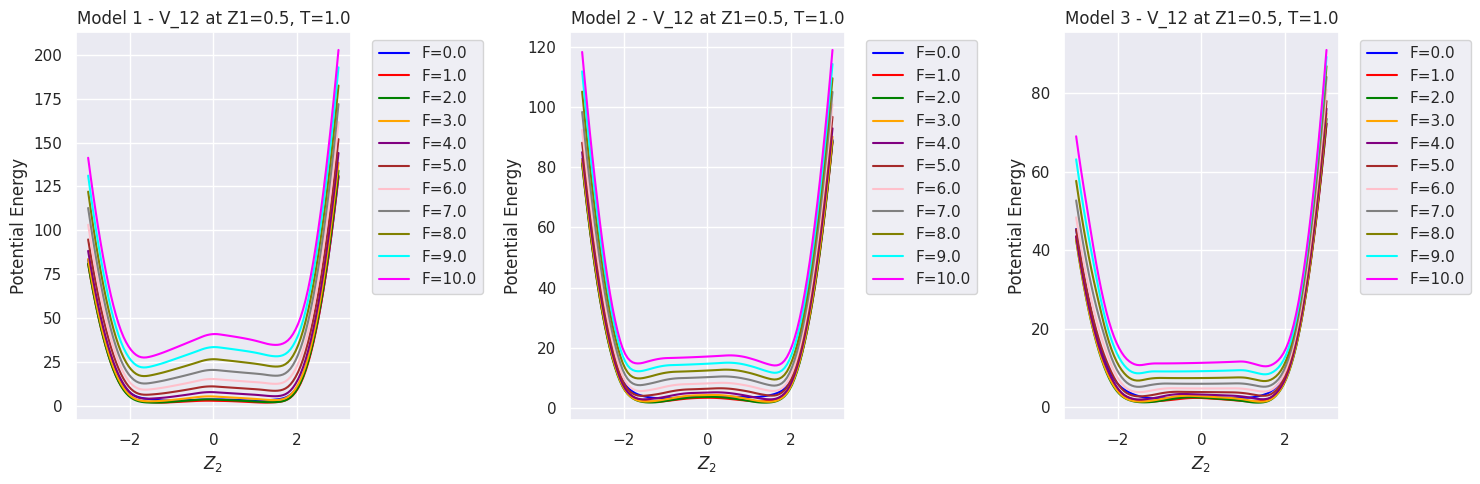

In [20]:
# Comparison of potentials at T=1.0 for F values 0-10

T_fixed = 1.0
F_values = jnp.linspace(0.0, 10.0, 11)  # F from 0 to 10

# Fixed z1 value for 1D plot
z1_fixed = 0.5
z2_range = jnp.linspace(z2_min, z2_max, num_grid)

# Compute potentials for each model and F value
potentials = []
for i, model in enumerate(models):
    model_potentials = []
    for F in F_values:
        @jax.jit
        def V_model(z1, z2, z3, T, F):
            args = jnp.array([T, F])
            coords = jnp.array([z1, z2, z3])
            return model.potential(coords, args)

        @jax.jit
        def V_12_model(z1, z2, T, F):
            z3_test_range = jnp.linspace(z3_min, z3_max, num_samples_aux_dimension)
            return jnp.min(jax.vmap(V_model, (None, None, 0, None, None))(z1, z2, z3_test_range, T, F))

        V_12_values = jax.vmap(V_12_model, in_axes=(None, 0, None, None))(z1_fixed, z2_range, T_fixed, F)
        model_potentials.append(V_12_values)
    potentials.append(model_potentials)

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta']

for i, (ax, model_pots) in enumerate(zip(axes, potentials)):
    for j, (F, V_vals) in enumerate(zip(F_values, model_pots)):
        ax.plot(z2_range, V_vals, color=colors[j % len(colors)], label=f'F={F:.1f}')
    ax.set_xlabel(r'$Z_2$')
    ax.set_ylabel('Potential Energy')
    ax.set_title(f'Model {i+1} - V_12 at Z1={z1_fixed}, T={T_fixed}')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1878304/4155122265.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


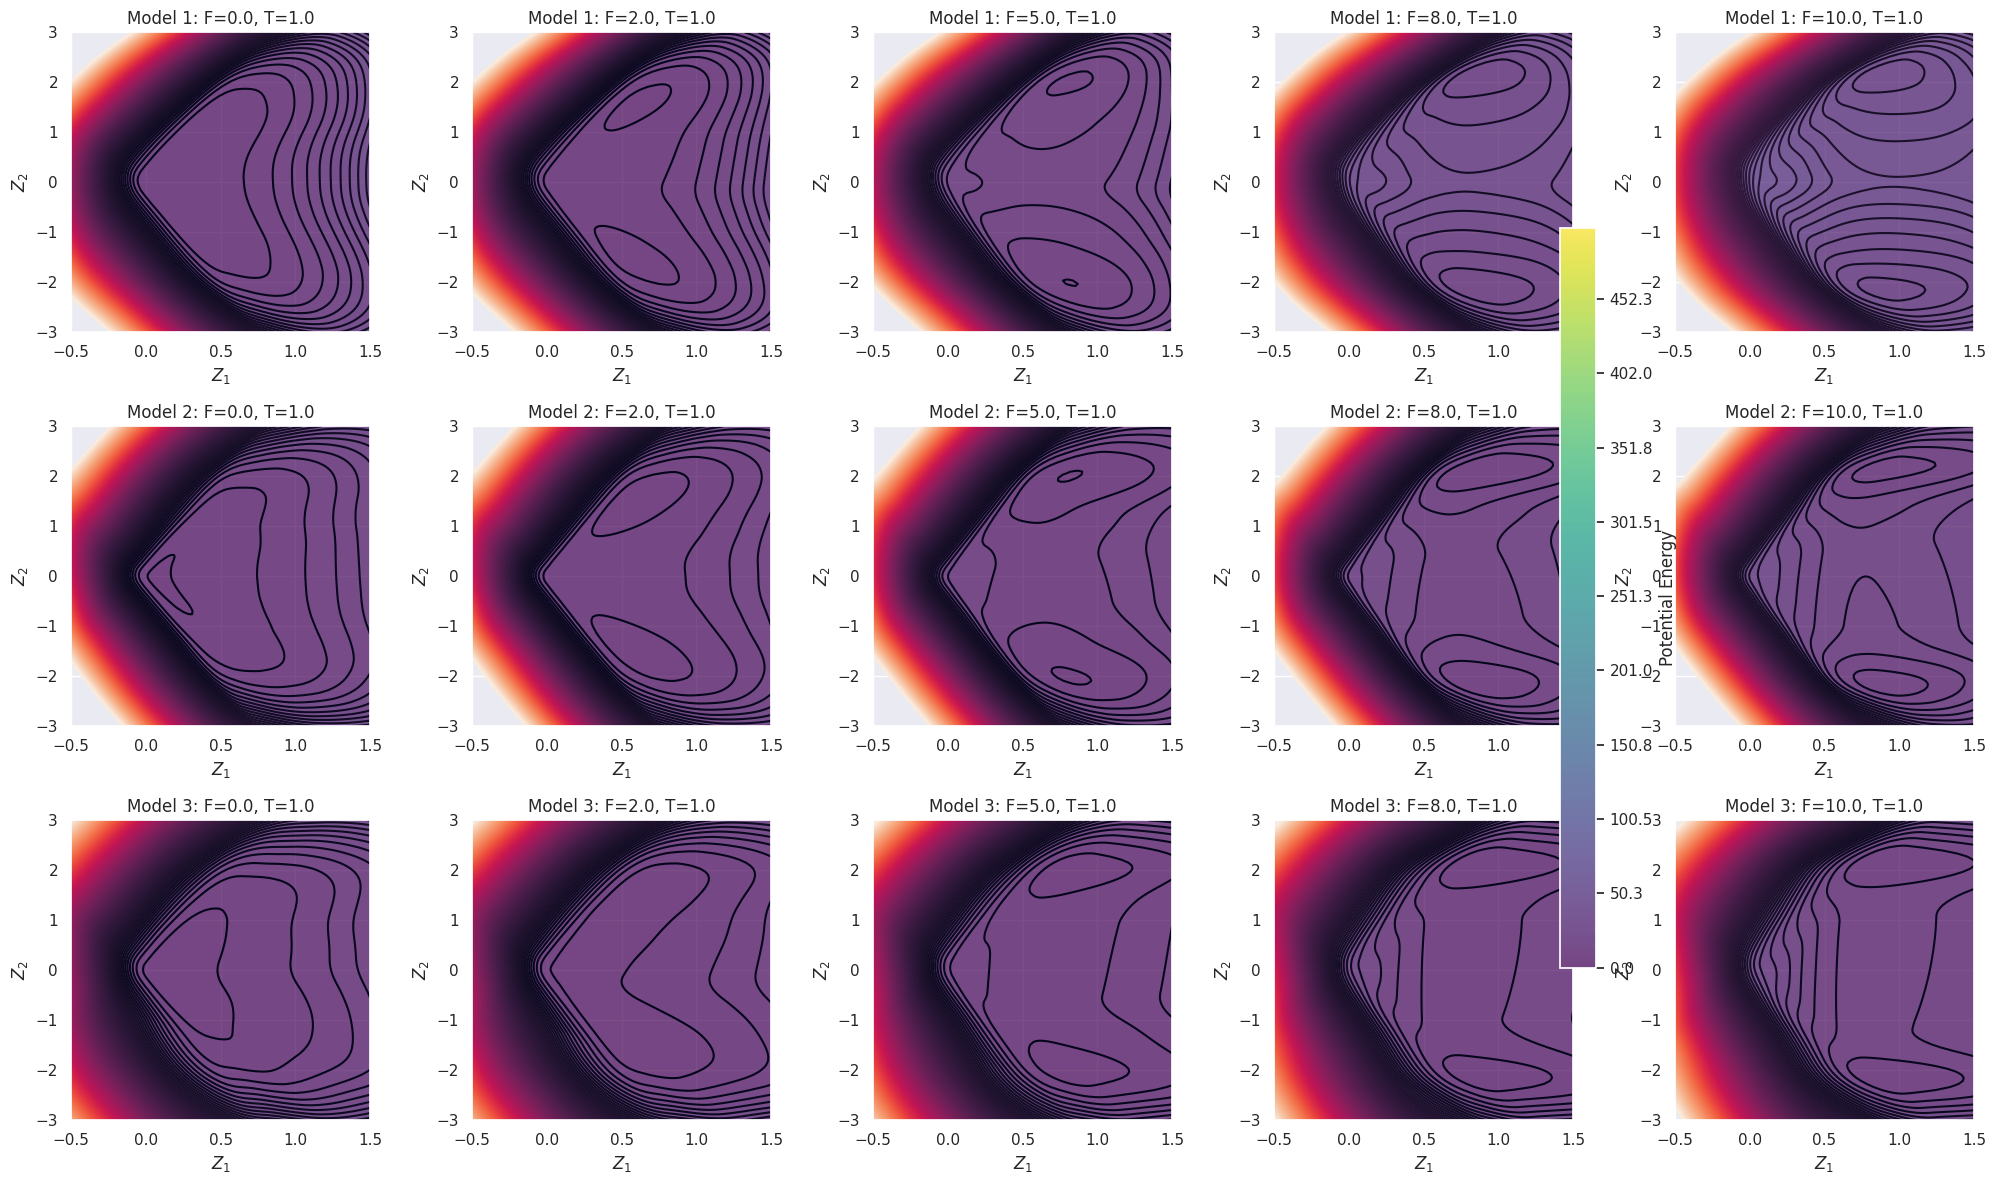

In [22]:
# Contour plots at different F values for each model (T=1.0)

T_fixed = 1.0
F_values_contour = [0.0, 2.0, 5.0, 8.0, 10.0]  # Select key F values

# Create subplots: rows for models, columns for F values
fig, axes = plt.subplots(len(models), len(F_values_contour), figsize=(20, 4 * len(models)))

for i, model in enumerate(models):
    for j, F in enumerate(F_values_contour):
        # Define model-specific potential function
        @jax.jit
        def V_model(z1, z2, z3, T, F):
            args = jnp.array([T, F])
            coords = jnp.array([z1, z2, z3])
            return model.potential(coords, args)

        @jax.jit
        def V_12_model(z1, z2, T, F):
            z3_test_range = jnp.linspace(z3_min, z3_max, num_samples_aux_dimension)
            return jnp.min(jax.vmap(V_model, (None, None, 0, None, None))(z1, z2, z3_test_range, T, F))

        # Get the Z1, Z2 meshgrid and V12_grid values
        z1_range = jnp.linspace(z1_min, z1_max, num_grid)
        z2_range = jnp.linspace(z2_min, z2_max, num_grid)
        Z1, Z2 = jnp.meshgrid(z1_range, z2_range)
        V12_grid = jax.vmap(V_12_model, in_axes=(0, 0, None, None))(Z1.ravel(), Z2.ravel(), T_fixed, F).reshape(Z1.shape)

        # Create contour plot
        ax = axes[i, j] if len(models) > 1 else axes[j]
        contour = ax.contour(Z1, Z2, V12_grid, levels=custom_levels)
        contourf = ax.contourf(Z1, Z2, V12_grid, levels=custom_levels, cmap='viridis', alpha=0.7)

        # Add labels and title
        ax.set_xlabel(r'$Z_1$')
        ax.set_ylabel(r'$Z_2$')
        ax.set_title(f'Model {i+1}: F={F:.1f}, T={T_fixed:.1f}')

# Add a single color bar for all plots
cbar = fig.colorbar(contourf, ax=axes, shrink=0.8, aspect=20)
cbar.set_label('Potential Energy')

plt.tight_layout()
plt.show()